<a href="https://colab.research.google.com/github/bfbnfh55/CareerCourse/blob/main/67011216037_HumAID_Crisis_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 01 — จำแนกข้อมูลที่มีประโยชน์ในภาวะภัยพิบัติ
**Social Network and Media Analysis | ระดับปริญญาตรี | 150–180 นาที | CPU / Google Colab**

**ชื่อ–สกุล:** ………………  **รหัสนิสิต:** ………………  **วันที่:** ………………

**ผลลัพธ์การเรียนรู้:** ตรวจคุณภาพข้อความและความไม่สมดุลของคลาส; สร้าง TF–IDF + Logistic Regression; ใช้ validation เลือกโมเดล; อ่านข้อผิดพลาดและแยก prediction ออกจากข้อเท็จจริง

**แหล่งข้อมูลต้นฉบับ:** [HumAID — CrisisNLP](https://crisisnlp.qcri.org/humaid_dataset.html)

ใช้ **event-wise set1** ที่เผยแพร่พร้อมข้อความ ไม่ใช่ชุดครบทุกเหตุการณ์ เลือกเหตุการณ์หนึ่งที่มี train/dev/test แล้วลดข้อความซ้ำข้าม split; จึงไม่ใช่การทำซ้ำคะแนน benchmark ต้นฉบับ

## แผนการทำงาน
สำรวจ/ทำความสะอาด 35 นาที → baseline/validation 45 นาที → วิเคราะห์ผล 40 นาที → งานนิสิต 45 นาที → สรุป 15 นาที

## ก่อนเริ่ม
1. เปิด [Google Colab](https://colab.research.google.com/) → Upload notebook → เลือกไฟล์นี้ → บันทึกสำเนาใน Drive ของตนเอง
2. เลือก Python 3 / CPU runtime แล้วรันจากบนลงล่าง ครั้งแรกต้องใช้อินเทอร์เน็ตดาวน์โหลดข้อมูล
3. พื้นฐานที่ใช้: Python function, list/dict, pandas DataFrame; อ่านคำอธิบายก่อนรันแต่ละขั้น
4. Cell ตัวอย่างรันได้ครบ ส่วน **งานนิสิต** ต้องเพิ่มการทดลองและเขียนเหตุผลด้วยตนเอง
5. เก็บผลเชิงสรุปและอ้างอิงเจ้าของข้อมูล หลีกเลี่ยงแสดงชื่อบัญชี/ข้อความส่วนบุคคลในรายงานโดยไม่จำเป็น

## 1. เตรียมเครื่องมือ

In [1]:
import importlib.util, subprocess, sys
packages = {'numpy':'numpy', 'pandas':'pandas>=2.0,<3',
            'matplotlib':'matplotlib>=3.7,<4', 'sklearn':'scikit-learn>=1.4,<2',
            'networkx':'networkx>=3.2,<4', 'PIL':'pillow>=10,<13', 'scipy':'scipy'}
missing = [spec for mod, spec in packages.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
print('Packages ready. ใช้ CPU runtime ได้ทุกแล็บ')

Packages ready. ใช้ CPU runtime ได้ทุกแล็บ


In [2]:
LAB_ID = 'snma_lab01'

import os, re, io, json, time, hashlib, tarfile, zipfile, shutil, platform
import urllib.request, urllib.error
from pathlib import Path, PurePosixPath
from collections import Counter, defaultdict
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import sklearn
from IPython.display import display

SEED = 42
np.random.seed(SEED)
BASE = Path('/content') if Path('/content').exists() else Path.cwd()
LAB_ROOT = BASE / LAB_ID
CACHE = Path(os.environ.get('SNMA_DATA_CACHE', str(LAB_ROOT / 'data')))
OUT = LAB_ROOT / 'results'
CACHE.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False})
RUN = {'lab':LAB_ID, 'seed':SEED, 'started_utc':datetime.now(timezone.utc).isoformat(),
       'python':platform.python_version(), 'pandas':pd.__version__,
       'numpy':np.__version__, 'sklearn':sklearn.__version__, 'networkx':nx.__version__,
       'sources':[]}

def file_hash(path, algorithm='sha256'):
    h = hashlib.new(algorithm)
    with open(path, 'rb') as f:
        for chunk in iter(lambda:f.read(1024*1024), b''): h.update(chunk)
    return h.hexdigest()

def fetch(url, filename, expected_md5=None):
    """Download public data, cache atomically, and record provenance; never substitute fake data."""
    path = CACHE / filename
    if not path.exists() or path.stat().st_size == 0:
        print('Downloading', filename, '...')
        error = None
        for attempt in range(3):
            try:
                # A fresh query avoids an expired cached redirect on Figshare downloads.
                request_url = url
                if 'ndownloader.figshare.com/files/' in url:
                    request_url += ('&' if '?' in url else '?') + 'download=1&cache=' + str(time.time_ns())
                req = urllib.request.Request(request_url, headers={'User-Agent':'SNMA-Teaching-Notebook/1.0'})
                with urllib.request.urlopen(req, timeout=120) as response, open(str(path)+'.part','wb') as f:
                    if response.status != 200: raise RuntimeError(f'HTTP {response.status}: download not ready')
                    shutil.copyfileobj(response, f, length=1024*1024)
                tmp = Path(str(path)+'.part')
                if tmp.stat().st_size == 0: raise RuntimeError('Empty download')
                tmp.replace(path)
                break
            except Exception as exc:
                error = exc
                if attempt < 2: time.sleep(2)
        else:
            raise RuntimeError(f'ดาวน์โหลด {filename} ไม่สำเร็จ ให้ดาวน์โหลดจากหน้า dataset '
                               f'แล้วอัปโหลดไฟล์ชื่อนี้เข้า {CACHE}; จากนั้นรัน cell นี้ใหม่. {error}')
    if expected_md5 and file_hash(path, 'md5') != expected_md5:
        raise ValueError(f'Checksum ไม่ตรง: {path}; ตรวจไฟล์ก่อนใช้')
    entry = {'url':url, 'filename':filename, 'bytes':path.stat().st_size, 'sha256':file_hash(path)}
    RUN['sources'] = [x for x in RUN['sources'] if x['filename'] != filename] + [entry]
    print(filename, f'{path.stat().st_size/1e6:.2f} MB')
    return path

def require_columns(df, names, context):
    missing = set(names) - set(df.columns)
    if missing: raise ValueError(f'{context}: missing {missing}; found {list(df.columns)}')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'^\s*rt\s+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def save_figure(name):
    plt.tight_layout()
    plt.savefig(OUT / name, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close()

def record_run(**kwargs):
    RUN.update(kwargs)
    (OUT/'run_manifest.json').write_text(json.dumps(RUN, ensure_ascii=False, indent=2, default=str), encoding='utf-8')
    print('Saved:', OUT)

def classification_scores(y, pred, labels):
    from sklearn.metrics import accuracy_score, f1_score
    return {'accuracy':accuracy_score(y,pred),
            'macro_f1':f1_score(y,pred,labels=labels,average='macro',zero_division=0),
            'weighted_f1':f1_score(y,pred,labels=labels,average='weighted',zero_division=0)}

## 2. โหลดไฟล์ต้นฉบับและตรวจ split
ไฟล์มี `tweet_id`, `tweet_text`, `class_label` อ่าน ID เป็น string เพื่อไม่เสียความแม่นยำ
สำรวจทุกโฟลเดอร์แบบ recursive เพราะ archive มีโฟลเดอร์ซ้อน เลือก event จาก **ชื่อไฟล์** ไม่ใช่ตำแหน่ง parent

In [3]:
archive = fetch('https://crisisnlp.qcri.org/data/humaid/HumAID_data_events_set1_47K.tar.gz',
                'HumAID_data_events_set1_47K.tar.gz')
tables = []
with tarfile.open(archive, 'r:gz') as tf:
    for member in tf:
        name = PurePosixPath(member.name).name
        match = re.fullmatch(r'(.+)_(train|dev|test)\.tsv', name)
        if not member.isfile() or not match or name.startswith('._'): continue
        part = pd.read_csv(tf.extractfile(member), sep='\t', dtype=str)
        require_columns(part, ['tweet_id','tweet_text','class_label'], name)
        part['event'], part['split'] = match.groups()
        tables.append(part)
all_events = pd.concat(tables, ignore_index=True)
display(pd.crosstab(all_events.event, all_events.split))
EVENT = 'hurricane_harvey_2017'  # เปลี่ยนเป็นชื่อจากตารางได้
if EVENT not in set(all_events.event):
    EVENT = all_events.event.value_counts().index[0]
    print('ใช้ event ที่มีข้อมูลมากที่สุดใน set1:', EVENT)
data = all_events.loc[all_events.event.eq(EVENT)].copy()
print('Selected:', EVENT, 'rows:', len(data))

HumAID_data_events_set1_47K.tar.gz 2.64 MB


split,dev,test,train
event,,,
canada_wildfires_2016,228,445,1569
cyclone_idai_2019,401,779,2753
ecuador_earthquake_2016,159,310,1094
greece_wildfires_2018,154,301,1060
hurricane_harvey_2017,929,1805,6378
hurricane_irma_2017,958,1862,6579
hurricane_maria_2017,742,1442,5094
hurricane_matthew_2016,168,329,1157
italy_earthquake_aug_2016,122,239,840


Selected: hurricane_harvey_2017 rows: 9112


## 3. ทำความสะอาดโดยไม่เรียนรู้จาก test
เก็บคลาสตามที่มีในเหตุการณ์; URL และชื่อบัญชีถูกตัดออกจาก input ข้อความ
คง train ก่อน แล้วเอา ID หรือ normalized text ที่ซ้ำออกจาก dev/test พร้อมรายงานจำนวนที่ตัด
การตรวจซ้ำนี้ยังไม่ตรวจ near-duplicate; ให้กล่าวถึงในข้อจำกัด

Classes absent from training: []


,split,before,after,removed
0,train,6378,6378,0
1,dev,929,929,0
2,test,1805,1805,0


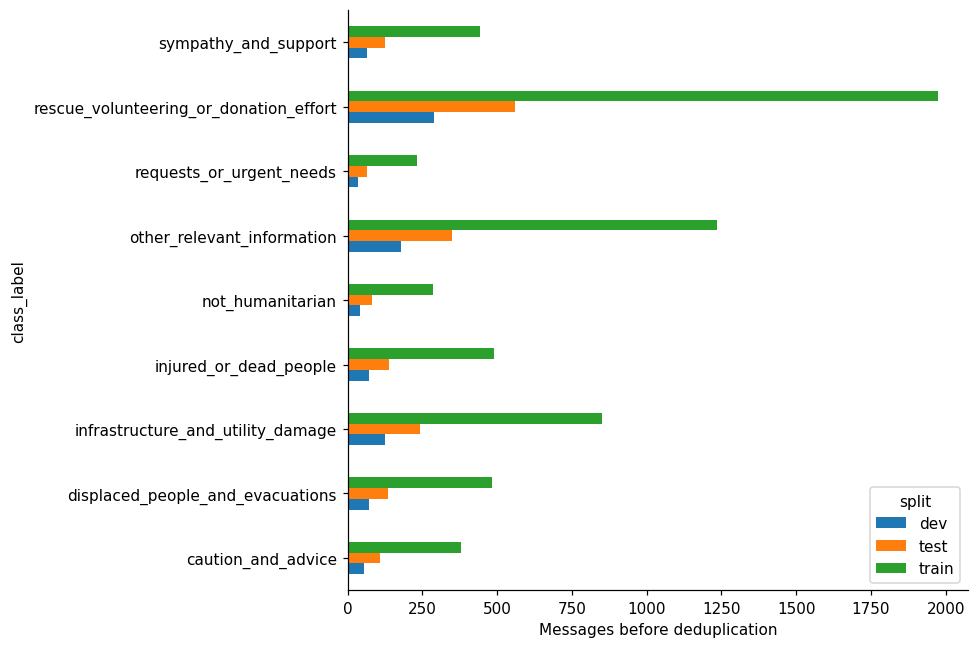

In [4]:
data = data.dropna(subset=['tweet_id','tweet_text','class_label']).copy()
data['text'] = data.tweet_text.map(clean_text)
data = data.loc[data.text.str.len().gt(0)].copy()
seen_ids, seen_texts, splits, audit = set(), set(), {}, []
for split in ['train','dev','test']:
    part = data.loc[data.split.eq(split)].copy()
    before = len(part)
    part = part.drop_duplicates('tweet_id').drop_duplicates('text')
    part = part.loc[~part.tweet_id.isin(seen_ids) & ~part.text.isin(seen_texts)].copy()
    seen_ids.update(part.tweet_id); seen_texts.update(part.text)
    splits[split] = part
    audit.append({'split':split, 'before':before, 'after':len(part), 'removed':before-len(part)})
train, dev, test = [splits[s] for s in ['train','dev','test']]
assert all(len(s)>0 for s in [train,dev,test])
assert set(train.tweet_id).isdisjoint(test.tweet_id)
assert set(train.text).isdisjoint(test.text)
LABELS = sorted(data.class_label.unique())
print('Classes absent from training:', sorted(set(test.class_label)-set(train.class_label)))
audit = pd.DataFrame(audit); display(audit)
audit.to_csv(OUT/'split_audit.csv',index=False)
pd.crosstab(data.class_label,data.split).plot.barh(figsize=(9,6))
plt.xlabel('Messages before deduplication'); save_figure('class_distribution.png')

## 4. สร้าง baseline และเลือก C ด้วย dev
TF–IDF ให้น้ำหนักคำตามความถี่ในข้อความและความหายากใน training corpus
`Pipeline` ทำให้ vocabulary/IDF ถูก fit เฉพาะ train ส่วน `class_weight='balanced'` ปรับน้ำหนักการฝึก
Macro-F1 ให้ความสำคัญแต่ละคลาสเท่ากัน; Accuracy อาจดูดีเพราะคลาสใหญ่
กำหนดชุดคลาสในการคำนวณ Macro-F1 ให้เหมือนกันทุกโมเดล (`zero_division=0`)

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

models, validation = {}, []
for C in [0.3, 1.0, 3.0]:
    model = Pipeline([
        ('tfidf',TfidfVectorizer(ngram_range=(1,2),min_df=2,max_features=15000,sublinear_tf=True)),
        ('clf',LogisticRegression(C=C,class_weight='balanced',max_iter=1200,random_state=SEED))])
    model.fit(train.text,train.class_label)
    models[C] = model
    validation.append({'C':C,**classification_scores(dev.class_label,model.predict(dev.text),LABELS)})
validation = pd.DataFrame(validation)
display(validation)
best_C = float(validation.sort_values(['macro_f1','C'],ascending=[False,True]).iloc[0]['C'])
best = models[best_C]  # ไม่ refit ด้วย dev ในตัวอย่างนี้
dummy = DummyClassifier(strategy='most_frequent').fit(train.text,train.class_label)
validation.to_csv(OUT/'validation_scores.csv',index=False)
print('C selected using dev:',best_C)

,C,accuracy,macro_f1,weighted_f1
0,0.3,0.674919,0.664002,0.682921
1,1.0,0.706136,0.683927,0.711873
2,3.0,0.708288,0.679166,0.712148


C selected using dev: 1.0


## 5. ประเมิน test ครั้งเดียวและอ่านข้อผิดพลาด

,model,accuracy,macro_f1,weighted_f1
0,Majority baseline,0.309695,0.052547,0.146463
1,TFIDF + LR,0.691967,0.649970,0.698775


                                        precision    recall  f1-score   support

                    caution_and_advice       0.55      0.58      0.56       107
      displaced_people_and_evacuations       0.85      0.90      0.88       136
     infrastructure_and_utility_damage       0.86      0.86      0.86       241
                injured_or_dead_people       0.86      0.88      0.87       139
                      not_humanitarian       0.23      0.36      0.28        81
            other_relevant_information       0.55      0.47      0.50       350
              requests_or_urgent_needs       0.35      0.58      0.43        66
rescue_volunteering_or_donation_effort       0.84      0.75      0.79       559
                  sympathy_and_support       0.66      0.69      0.67       126

                              accuracy                           0.69      1805
                             macro avg       0.64      0.67      0.65      1805
                          weighted avg

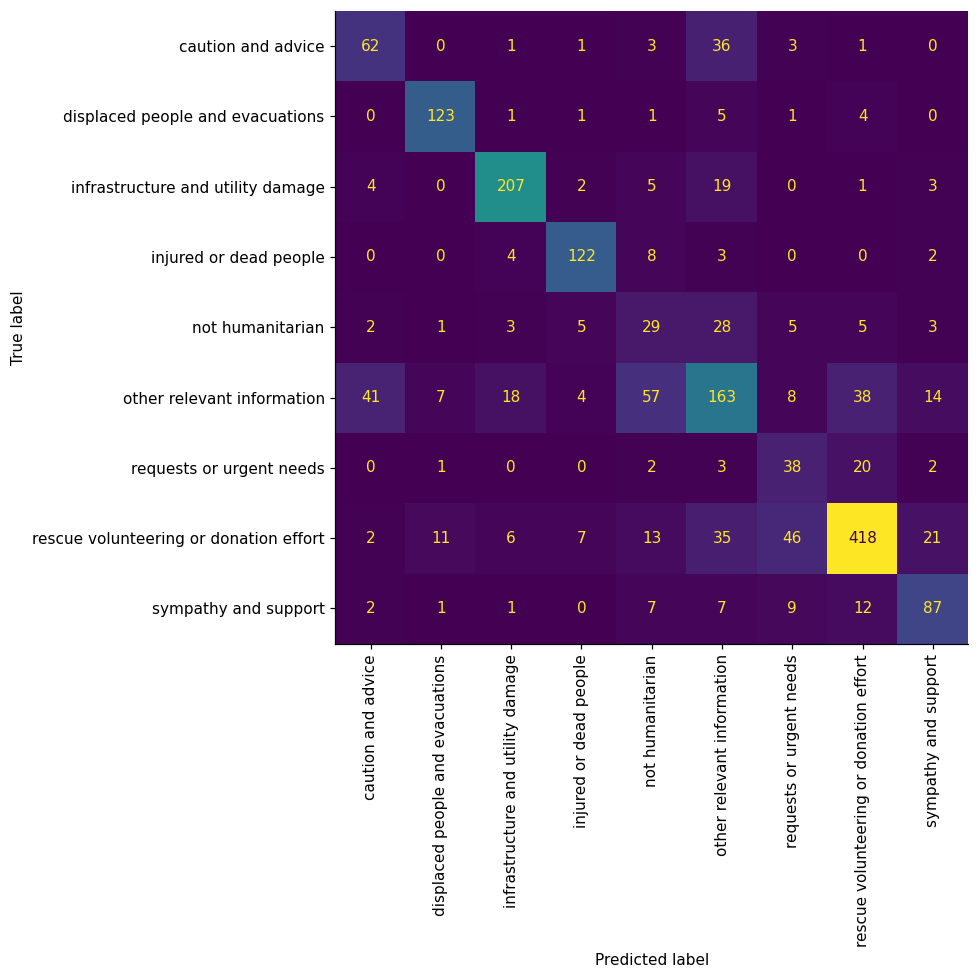

,tweet_id,class_label,text,prediction
32102,903458068217913345,infrastructure_and_utility_damage,can you not use a tragedy that destroyed my co...,not_humanitarian
32110,902889963007733760,other_relevant_information,ive been wanting to complain this week ab the ...,not_humanitarian
32113,902634170983251973,sympathy_and_support,"thank you everybody, what a crowd, what a turn...",not_humanitarian
32114,903049140304797696,rescue_volunteering_or_donation_effort,the people living &amp; working in these areas...,sympathy_and_support
32115,902637509343105024,not_humanitarian,years of living dangerously. #hurricaneharvey ...,other_relevant_information
32119,901568556432805888,infrastructure_and_utility_damage,extensive damage in texas. at least 1 dead &am...,injured_or_dead_people
32121,902707244919390208,rescue_volunteering_or_donation_effort,were offering one month of free #bookkeepingse...,sympathy_and_support
32124,902632926084567040,displaced_people_and_evacuations,burger stadium in austin now open as evacuee c...,requests_or_urgent_needs


In [6]:
pred = best.predict(test.text)
scores = pd.DataFrame([
    {'model':'Majority baseline',**classification_scores(test.class_label,dummy.predict(test.text),LABELS)},
    {'model':'TFIDF + LR',**classification_scores(test.class_label,pred,LABELS)}])
display(scores)
print(classification_report(test.class_label,pred,labels=LABELS,zero_division=0))
fig,ax = plt.subplots(figsize=(10,9))
ConfusionMatrixDisplay.from_predictions(test.class_label,pred,labels=LABELS,
    display_labels=[s.replace('_',' ') for s in LABELS],xticks_rotation=90,ax=ax,colorbar=False)
save_figure('confusion_matrix.png')
errors = test[['tweet_id','class_label','text']].copy()
errors['prediction'] = pred
display(errors.loc[errors.class_label.ne(errors.prediction)].head(8))
# ส่งเฉพาะ ID/label/prediction ไม่บันทึกข้อความลงผลลัพธ์
errors.drop(columns='text').to_csv(OUT/'predictions.csv',index=False)
scores.to_csv(OUT/'model_scores.csv',index=False)

## 6. อ่านคำที่สัมพันธ์กับการตัดสินของโมเดล
สัมประสิทธิ์บวกสูงหมายถึงสัมพันธ์กับคลาสนั้น **ภายในโมเดลนี้** ไม่ใช่สาเหตุหรือหลักฐานว่าข้อความเป็นจริง

In [7]:
features = best.named_steps['tfidf'].get_feature_names_out()
clf = best.named_steps['clf']
coef = clf.coef_
if len(clf.classes_)==2: coef = np.vstack([-coef[0],coef[0]])
top = []
for label,weights in zip(clf.classes_,coef):
    for idx in np.argsort(weights)[-8:][::-1]:
        top.append({'class':label,'term':features[idx],'coefficient':weights[idx]})
top = pd.DataFrame(top); display(top)
top.to_csv(OUT/'top_terms.csv',index=False)
record_run(event=EVENT,split_audit=audit.to_dict('records'),labels=LABELS,best_C=best_C,
           evaluation='official event split, with exact ID/text deduplication')

,class,term,coefficient
0,caution_and_advice,tornado,5.574031
1,caution_and_advice,warning,3.835819
2,caution_and_advice,warnings,3.210529
3,caution_and_advice,flooding,2.679343
4,caution_and_advice,rain,2.579655
...,...,...,...
67,sympathy_and_support,thoughts,3.738292
68,sympathy_and_support,praying,3.167933
69,sympathy_and_support,support,3.003286
70,sympathy_and_support,pray for,2.753573


Saved: /content/snma_lab01/results


## งานนิสิต — 100 คะแนน

1. ตรวจจำนวนคลาส ข้อความซ้ำ และ class imbalance พร้อมหลักฐาน (20)
2. เปรียบเทียบ unigram กับ unigram+bigram โดยเลือกจาก dev และรายงาน test ของตัวเลือกที่ล็อกแล้ว (30)
3. วิเคราะห์ข้อผิดพลาด 5 ข้อความและคำสำคัญอย่างน้อย 2 คลาส (25)
4. อธิบายข้อจำกัดและทำ notebook รันซ้ำได้ (25)

## คำถามวิเคราะห์

1. เหตุใด baseline อาจมี Accuracy สูงแต่ Macro-F1 ต่ำ?
2. การ fit TF–IDF ก่อนแบ่งข้อมูลทำให้ข้อมูลรั่วไหลอย่างไร?
3. หากคลาสหนึ่งไม่มีใน train ควรตีความ test score อย่างไร?
4. โมเดลนี้ตัดสินความจริงหรือความเร่งด่วนทางปฏิบัติได้หรือไม่ เพราะอะไร?

## งานต่อยอด (เลือกทำ)

ย้ายเหตุการณ์ที่ฝึกไปทดสอบเหตุการณ์อื่น โดยตรวจข้อความซ้ำข้ามเหตุการณ์ และรายงานผลแยกตามคลาส; อย่ารวมชุดทดสอบเข้า train เพื่อปรับคะแนน

## สิ่งที่ต้องส่ง

- Notebook ที่รันแล้ว พร้อมโค้ดการทดลองของนิสิตและคำตอบใน Markdown cells
- รายงาน 1–2 หน้า: คำถาม → วิธี → หลักฐานเชิงตัวเลข/กราฟ → การตีความ → ข้อจำกัด
- ผลลัพธ์: `model_scores.csv`, `validation_scores.csv`, `predictions.csv`, `split_audit.csv`, `top_terms.csv`, กราฟ 2 ภาพ และ `run_manifest.json` ไม่ต้องส่งไฟล์ข้อมูลดิบ
- ระบุการใช้เครื่องมือช่วยเขียนโค้ด และอธิบายโค้ดที่ส่งได้ด้วยตนเอง

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


class_counts = train['class_label'].value_counts().sort_index()

print("จำนวนคลาสทั้งหมด:", len(LABELS))
print("\nจำนวนข้อมูลในแต่ละคลาส (Train):")
display(class_counts.to_frame('count'))

print("\nสัดส่วนข้อมูลแต่ละคลาส:")
class_ratio = (class_counts / len(train) * 100).round(2)
display(class_ratio.to_frame('percentage'))

imbalance_ratio = class_counts.max() / class_counts.min()

print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}")

experiments = {
    'Unigram': (1, 1),
    'Unigram + Bigram': (1, 2)
}

experiment_models = {}
experiment_validation = []

for name, ngram_range in experiments.items():

    model = Pipeline([
        (
            'tfidf',
            TfidfVectorizer(
                ngram_range=ngram_range,
                min_df=2,
                max_features=15000,
                sublinear_tf=True
            )
        ),
        (
            'clf',
            LogisticRegression(
                C=best_C,
                class_weight='balanced',
                max_iter=1200,
                random_state=SEED
            )
        )
    ])

    model.fit(train.text, train.class_label)

    dev_pred = model.predict(dev.text)

    scores_dev = classification_scores(
        dev.class_label,
        dev_pred,
        LABELS
    )

    experiment_models[name] = model

    experiment_validation.append({
        'model': name,
        **scores_dev
    })

experiment_validation = pd.DataFrame(experiment_validation)

print("ผลการทดลองบน DEV")
display(experiment_validation)


best_experiment_name = (
    experiment_validation
    .sort_values(
        ['macro_f1', 'accuracy'],
        ascending=[False, False]
    )
    .iloc[0]['model']
)

selected_model = experiment_models[best_experiment_name]

print("โมเดลที่เลือกจาก DEV:", best_experiment_name)


test_pred_selected = selected_model.predict(test.text)

selected_test_scores = classification_scores(
    test.class_label,
    test_pred_selected,
    LABELS
)

final_experiment_result = pd.DataFrame([{
    'model': best_experiment_name,
    **selected_test_scores
}])

print("\nผล TEST ของโมเดลที่เลือก")
display(final_experiment_result)

experiment_validation.to_csv(
    OUT / 'ngram_validation_scores.csv',
    index=False
)

final_experiment_result.to_csv(
    OUT / 'ngram_test_scores.csv',
    index=False
)

จำนวนคลาสทั้งหมด: 9

จำนวนข้อมูลในแต่ละคลาส (Train):


,count
class_label,
caution_and_advice,379
displaced_people_and_evacuations,482
infrastructure_and_utility_damage,852
injured_or_dead_people,488
not_humanitarian,287
other_relevant_information,1237
requests_or_urgent_needs,233
rescue_volunteering_or_donation_effort,1976
sympathy_and_support,444



สัดส่วนข้อมูลแต่ละคลาส:


,percentage
class_label,
caution_and_advice,5.94
displaced_people_and_evacuations,7.56
infrastructure_and_utility_damage,13.36
injured_or_dead_people,7.65
not_humanitarian,4.50
other_relevant_information,19.39
requests_or_urgent_needs,3.65
rescue_volunteering_or_donation_effort,30.98
sympathy_and_support,6.96



Imbalance ratio (max/min): 8.48
ผลการทดลองบน DEV


,model,accuracy,macro_f1,weighted_f1
0,Unigram,0.699677,0.677243,0.707070
1,Unigram + Bigram,0.706136,0.683927,0.711873


โมเดลที่เลือกจาก DEV: Unigram + Bigram

ผล TEST ของโมเดลที่เลือก


,model,accuracy,macro_f1,weighted_f1
0,Unigram + Bigram,0.691967,0.64997,0.698775


### 1. ตรวจสอบจำนวนคลาสและความสมดุลของข้อมูล

ในขั้นตอนแรก ตรวจสอบจำนวนข้อมูลในแต่ละคลาสของเหตุการณ์
`hurricane_harvey_2017` เพื่อดูการกระจายของข้อมูลและตรวจสอบปัญหา
Class Imbalance

จากผลการตรวจสอบ พบว่าข้อมูลมีทั้งหมด 9 คลาส ได้แก่

- caution_and_advice
- displaced_people_and_evacuations
- infrastructure_and_utility_damage
- injured_or_dead_people
- not_humanitarian
- other_relevant_information
- requests_or_urgent_needs
- rescue_volunteering_or_donation_effort
- sympathy_and_support

คลาสที่มีจำนวนข้อมูลมากที่สุดคือ `rescue_volunteering_or_donation_effort`
จำนวน 1,976 ข้อความ หรือประมาณ 30.98%

ส่วนคลาสที่มีจำนวนข้อมูลน้อยที่สุดคือ `requests_or_urgent_needs`
จำนวน 233 ข้อความ หรือประมาณ 3.65%

เมื่อคำนวณ Imbalance Ratio จากจำนวนข้อมูลสูงสุดหารด้วยจำนวนข้อมูลต่ำสุด
ได้ค่า 8.48 แสดงว่าการกระจายข้อมูลระหว่างคลาสไม่สมดุลกันค่อนข้างมาก

ดังนั้น ในการสร้างโมเดลจึงต้องพิจารณา Macro-F1 ร่วมกับ Accuracy
เพื่อไม่ให้ผลการประเมินได้รับอิทธิพลจากคลาสที่มีจำนวนข้อมูลมากเพียงอย่างเดียว

# 2. เปรียบเทียบ Unigram และ Unigram + Bigram

ในการทดลองนี้ เปรียบเทียบการแทนข้อความด้วย TF-IDF สองรูปแบบ ได้แก่

1. Unigram: ใช้คำทีละคำ
2. Unigram + Bigram: ใช้ทั้งคำเดี่ยวและคู่คำที่อยู่ติดกัน

ใช้ข้อมูล DEV สำหรับเปรียบเทียบและเลือกโมเดลก่อนที่จะนำโมเดลที่เลือก
ไปประเมินบน TEST เพื่อป้องกันการใช้ TEST ในการตัดสินใจเลือกโมเดล

## ผลการทดลองบน DEV

ผลการทดลองพบว่า

- Unigram: Accuracy = 0.699677, Macro-F1 = 0.677243
- Unigram + Bigram: Accuracy = 0.706136, Macro-F1 = 0.683927

โมเดล Unigram + Bigram มีค่า Accuracy และ Macro-F1 สูงกว่า
Unigram เล็กน้อย จึงเลือก Unigram + Bigram สำหรับการประเมินบน TEST

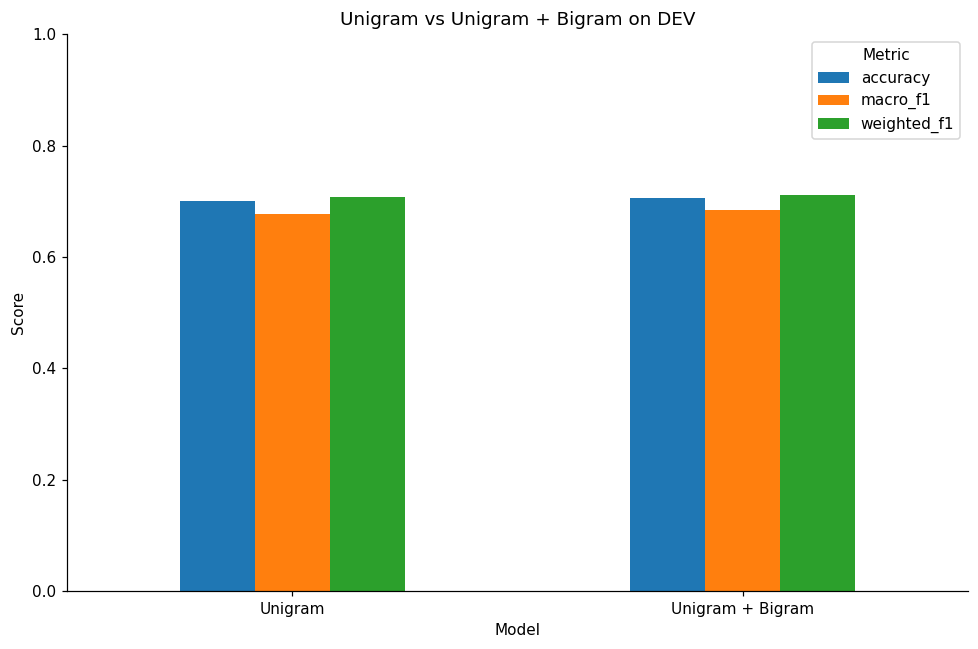

In [11]:
plot_df = experiment_validation.set_index('model')[
    ['accuracy', 'macro_f1', 'weighted_f1']
]

ax = plot_df.plot(
    kind='bar',
    figsize=(9, 6)
)

ax.set_title('Unigram vs Unigram + Bigram on DEV')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title='Metric')

save_figure('ngram_comparison.png')

## ผลการประเมินบน TEST

หลังจากเลือกโมเดลจาก DEV แล้ว จึงนำโมเดลที่เลือกไปประเมินบน TEST

ผลการทดลองของ Unigram + Bigram บน TEST คือ

- Accuracy = 0.691967
- Macro-F1 = 0.649970
- Weighted-F1 = 0.698775

พบว่าค่า Macro-F1 บน TEST ต่ำกว่าบน DEV แสดงว่าประสิทธิภาพของโมเดล
ลดลงเมื่อทดสอบกับข้อมูลที่ไม่ได้ใช้ในการเลือกโมเดล

In [12]:
error_analysis = test[
    test.class_label != test_pred_selected
][['tweet_id', 'class_label', 'text']].copy()

error_analysis['prediction'] = test_pred_selected[
    test.class_label != test_pred_selected
]

error_analysis['correct'] = False

print("จำนวน prediction ผิดทั้งหมด:", len(error_analysis))

print("\nตัวอย่างข้อผิดพลาด 5 รายการ")
display(error_analysis.head(5))

จำนวน prediction ผิดทั้งหมด: 556

ตัวอย่างข้อผิดพลาด 5 รายการ


,tweet_id,class_label,text,prediction,correct
32102,903458068217913345,infrastructure_and_utility_damage,can you not use a tragedy that destroyed my co...,not_humanitarian,False
32110,902889963007733760,other_relevant_information,ive been wanting to complain this week ab the ...,not_humanitarian,False
32113,902634170983251973,sympathy_and_support,"thank you everybody, what a crowd, what a turn...",not_humanitarian,False
32114,903049140304797696,rescue_volunteering_or_donation_effort,the people living &amp; working in these areas...,sympathy_and_support,False
32115,902637509343105024,not_humanitarian,years of living dangerously. #hurricaneharvey ...,other_relevant_information,False


# 3. Error Analysis

หลังจากประเมินโมเดลบน TEST พบว่ามีข้อความที่โมเดลทำนายผิดทั้งหมด 556 ข้อความ

ตัวอย่างข้อผิดพลาด 5 รายการถูกนำมาตรวจสอบเพื่อทำความเข้าใจลักษณะของข้อความ
ที่โมเดลสับสนระหว่างคลาส

ตัวอย่างที่ 1:
คลาสจริงคือ `infrastructure_and_utility_damage`
แต่โมเดลทำนายเป็น `not_humanitarian`

ตัวอย่างที่ 2:
คลาสจริงคือ `other_relevant_information`
แต่โมเดลทำนายเป็น `not_humanitarian`

ตัวอย่างที่ 3:
คลาสจริงคือ `sympathy_and_support`
แต่โมเดลทำนายเป็น `not_humanitarian`

ตัวอย่างที่ 4:
คลาสจริงคือ `rescue_volunteering_or_donation_effort`
แต่โมเดลทำนายเป็น `sympathy_and_support`

ตัวอย่างที่ 5:
คลาสจริงคือ `not_humanitarian`
แต่โมเดลทำนายเป็น `other_relevant_information`

จากตัวอย่างพบว่า ข้อความบางประเภทมีคำศัพท์หรือบริบทที่สามารถพบได้ในหลายคลาส
ทำให้การจำแนกจากข้อความเพียงอย่างเดียวทำได้ยาก โดยเฉพาะข้อความที่มีบริบทสั้น
หรือไม่ได้ระบุเหตุการณ์และเจตนาอย่างชัดเจน

In [13]:
print("คำที่มีน้ำหนักสูงสำหรับแต่ละคลาส")

for label in LABELS[:2]:

    subset = top[top['class'] == label].copy()

    print("\nClass:", label)

    display(
        subset[
            ['term', 'coefficient']
        ].sort_values(
            'coefficient',
            ascending=False
        )
    )

คำที่มีน้ำหนักสูงสำหรับแต่ละคลาส

Class: caution_and_advice


,term,coefficient
0,tornado,5.574031
1,warning,3.835819
2,warnings,3.210529
3,flooding,2.679343
4,rain,2.579655
5,emergency,2.496132
6,flood,2.337634
7,tornado warnings,2.300034



Class: displaced_people_and_evacuations


,term,coefficient
8,evacuees,9.002093
9,displaced,8.274928
10,evacuation,7.869749
11,evacuations,5.637805
12,evacuated,4.133626
13,evacuate,3.992538
14,harvey evacuees,3.565583
15,displaced by,3.192206


# 4. คำสำคัญที่มีน้ำหนักสูงของแต่ละคลาส

เพื่อทำความเข้าใจว่าโมเดลใช้คำใดเป็นปัจจัยสำคัญในการจำแนกคลาส
จึงตรวจสอบค่าสัมประสิทธิ์ (coefficient) ของ TF-IDF + Logistic Regression

คำที่มี coefficient สูง แสดงว่าโมเดลให้น้ำหนักกับคำนั้นมากในการสนับสนุน
การทำนายคลาสนั้น

ตัวอย่างเช่น

- `caution_and_advice` มีคำสำคัญ เช่น `tornado`, `warning`, `warnings`,
  `flooding` และ `emergency`
- `displaced_people_and_evacuations` มีคำสำคัญ เช่น `evacuees`,
  `displaced`, `evacuation`, `evacuations` และ `evacuated`

คำเหล่านี้มีความสัมพันธ์กับความหมายของคลาส เช่น คำว่า
`evacuees`, `displaced` และ `evacuation` สื่อถึงสถานการณ์การอพยพหรือ
การพลัดถิ่น จึงมีประโยชน์ต่อการจำแนกข้อความในคลาสดังกล่าว

In [14]:
result_zip = shutil.make_archive(
    str(LAB_ROOT / (LAB_ID + '_results')),
    'zip',
    OUT
)

try:
    from google.colab import files
    files.download(result_zip)
except ImportError:
    print(result_zip)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 5. คำถามวิเคราะห์

## 5.1 ทำไม Baseline อาจมี Accuracy สูง แต่ Macro-F1 ต่ำ?

Accuracy วัดสัดส่วนการทำนายถูกจากข้อมูลทั้งหมด ดังนั้นเมื่อข้อมูลมี
Class Imbalance โมเดลอาจทำนายคลาสที่มีจำนวนข้อมูลมากได้ถูกต้องจำนวนมาก
และทำให้ Accuracy สูง

แต่ Macro-F1 จะคำนวณ F1-score ของแต่ละคลาสแล้วนำมาเฉลี่ยโดยให้น้ำหนัก
แต่ละคลาสเท่ากัน ดังนั้นหากโมเดลทำนายคลาสขนาดเล็กได้ไม่ดี
Macro-F1 จะลดลง

จากข้อมูลการทดลองนี้พบว่าการกระจายของข้อมูลไม่สมดุล โดยคลาสที่มีข้อมูลมากที่สุด
มีจำนวนมากกว่าคลาสที่มีข้อมูลน้อยที่สุดประมาณ 8.48 เท่า จึงควรพิจารณา
Macro-F1 ร่วมกับ Accuracy

## 5.2 การ Fit TF-IDF ก่อนแบ่งข้อมูลทำให้เกิด Data Leakage ได้อย่างไร?

TF-IDF ต้องเรียนรู้ข้อมูล เช่น vocabulary และค่า IDF จากข้อมูลที่ใช้ fit

หากสร้าง TF-IDF จากข้อมูลทั้งหมดก่อนแบ่งเป็น train/dev/test
ข้อมูลจาก dev และ test จะมีส่วนในการกำหนด vocabulary และ IDF
ทำให้ข้อมูลจากชุดทดสอบมีอิทธิพลต่อกระบวนการเตรียมข้อมูล

สถานการณ์นี้เรียกว่า Data Leakage เพราะข้อมูลที่ควรเป็นข้อมูลที่โมเดล
ไม่เคยเห็นมาก่อนมีส่วนในการสร้าง representation ของข้อมูล

วิธีที่ใช้ในการทดลองนี้คือใส่ TF-IDF ไว้ใน Pipeline เดียวกับ Logistic Regression
และ fit pipeline ด้วย train เท่านั้น จากนั้นจึงนำไปใช้กับ dev และ test

## 5.3 ถ้าคลาสหนึ่งไม่มีอยู่ใน Train ควรตีความ Test Score อย่างไร?

หากคลาสหนึ่งไม่มีตัวอย่างใน Train โมเดลจะไม่มีข้อมูลฝึกสำหรับเรียนรู้
ลักษณะของคลาสนั้นโดยตรง

ดังนั้นผลการทำนายคลาสดังกล่าวบน Test อาจไม่มีความหมายในเชิงการเรียนรู้
แบบ supervised learning และไม่ควรสรุปว่าโมเดลสามารถจำแนกคลาสนั้นได้ดี

จึงต้องตรวจสอบ class distribution ระหว่าง Train และ Test ก่อนประเมินผล
และรายงานกรณีที่มีคลาสใน Test แต่ไม่มีใน Train อย่างชัดเจน

## 5.4 โมเดลสามารถตัดสินได้หรือไม่ว่าเหตุการณ์นั้นเป็น "ความจริง"
หรือมี "ความเร่งด่วนในทางปฏิบัติ"?

ไม่สามารถตัดสินได้โดยตรง

โมเดลนี้เป็นโมเดลสำหรับจำแนกข้อความตามรูปแบบที่เรียนรู้จากข้อมูลฝึก
เช่น จำแนกข้อความเป็น `requests_or_urgent_needs`,
`infrastructure_and_utility_damage` หรือคลาสอื่น ๆ

การทำนายของโมเดลไม่ได้หมายความว่าข้อความนั้นเป็นข้อเท็จจริงที่ผ่านการตรวจสอบแล้ว
และไม่ได้หมายความว่าเหตุการณ์นั้นมีความเร่งด่วนในทางปฏิบัติ

การตัดสินความจริงหรือระดับความเร่งด่วนจำเป็นต้องใช้ข้อมูลเพิ่มเติม เช่น
การตรวจสอบแหล่งข่าว บริบทของเหตุการณ์ เวลา สถานที่ และการยืนยันจากแหล่งข้อมูลอื่น

### งานต่อยอด

In [15]:
print("เหตุการณ์ที่ใช้ฝึก:", EVENT)

event_summary = (
    all_events
    .groupby(['event', 'split'])
    .size()
    .unstack(fill_value=0)
)

display(event_summary)

เหตุการณ์ที่ใช้ฝึก: hurricane_harvey_2017


split,dev,test,train
event,,,
canada_wildfires_2016,228,445,1569
cyclone_idai_2019,401,779,2753
ecuador_earthquake_2016,159,310,1094
greece_wildfires_2018,154,301,1060
hurricane_harvey_2017,929,1805,6378
hurricane_irma_2017,958,1862,6579
hurricane_maria_2017,742,1442,5094
hurricane_matthew_2016,168,329,1157
italy_earthquake_aug_2016,122,239,840


In [16]:
EXTERNAL_EVENT = 'hurricane_maria_2017'

if EXTERNAL_EVENT == EVENT:
    raise ValueError("EXTERNAL_EVENT ต้องเป็นคนละเหตุการณ์กับ EVENT")

if EXTERNAL_EVENT not in set(all_events.event):
    raise ValueError(
        f"ไม่พบ event: {EXTERNAL_EVENT}\n"
        f"กรุณาเลือกจากตาราง event_summary"
    )

print("External test event:", EXTERNAL_EVENT)

External test event: hurricane_maria_2017


In [18]:
external = all_events.loc[
    all_events.event.eq(EXTERNAL_EVENT)
].copy()

external = external.dropna(
    subset=['tweet_id', 'tweet_text', 'class_label']
).copy()

external['text'] = external.tweet_text.map(clean_text)

external = external.loc[
    external.text.str.len().gt(0)
].copy()

print("External event:", EXTERNAL_EVENT)
print("จำนวนข้อความก่อนตรวจซ้ำ:", len(external))

External event: hurricane_maria_2017
จำนวนข้อความก่อนตรวจซ้ำ: 7278


In [19]:
train_ids = set(train['tweet_id'])
train_texts = set(train['text'])

external_id_duplicate = external['tweet_id'].isin(train_ids)
external_text_duplicate = external['text'].isin(train_texts)

external['duplicate_id_with_train'] = external_id_duplicate
external['duplicate_text_with_train'] = external_text_duplicate

duplicate_summary = pd.DataFrame({
    'type': [
        'Duplicate tweet_id',
        'Duplicate normalized text'
    ],
    'count': [
        external_id_duplicate.sum(),
        external_text_duplicate.sum()
    ]
})

display(duplicate_summary)

,type,count
0,Duplicate tweet_id,0
1,Duplicate normalized text,0


In [20]:
before_dedup = len(external)

external = external.loc[
    ~external['duplicate_id_with_train'] &
    ~external['duplicate_text_with_train']
].copy()

removed = before_dedup - len(external)

print("External test ก่อน dedup:", before_dedup)
print("ลบข้อความซ้ำ:", removed)
print("External test หลัง dedup:", len(external))

External test ก่อน dedup: 7278
ลบข้อความซ้ำ: 0
External test หลัง dedup: 7278


In [21]:

external_class_counts = (
    external['class_label']
    .value_counts()
    .sort_index()
)

print("Classes ใน TRAIN:")
print(sorted(train.class_label.unique()))

print("\nClasses ใน EXTERNAL TEST:")
print(sorted(external.class_label.unique()))

display(
    external_class_counts.to_frame('count')
)

Classes ใน TRAIN:
['caution_and_advice', 'displaced_people_and_evacuations', 'infrastructure_and_utility_damage', 'injured_or_dead_people', 'not_humanitarian', 'other_relevant_information', 'requests_or_urgent_needs', 'rescue_volunteering_or_donation_effort', 'sympathy_and_support']

Classes ใน EXTERNAL TEST:
['caution_and_advice', 'displaced_people_and_evacuations', 'infrastructure_and_utility_damage', 'injured_or_dead_people', 'not_humanitarian', 'other_relevant_information', 'requests_or_urgent_needs', 'rescue_volunteering_or_donation_effort', 'sympathy_and_support']


,count
class_label,
caution_and_advice,220
displaced_people_and_evacuations,131
infrastructure_and_utility_damage,1427
injured_or_dead_people,302
not_humanitarian,270
other_relevant_information,1568
requests_or_urgent_needs,711
rescue_volunteering_or_donation_effort,1977
sympathy_and_support,672


In [22]:
unseen_external_classes = sorted(
    set(external.class_label) - set(train.class_label)
)

print(
    "Classes ที่มีใน External Test แต่ไม่มีใน Train:",
    unseen_external_classes
)

Classes ที่มีใน External Test แต่ไม่มีใน Train: []


In [23]:
external_pred = selected_model.predict(
    external['text']
)

external['prediction'] = external_pred

print("External prediction completed.")

External prediction completed.


In [24]:
from sklearn.metrics import classification_report

external_labels = sorted(
    set(external.class_label) |
    set(external_pred)
)

report_dict = classification_report(
    external.class_label,
    external_pred,
    labels=external_labels,
    zero_division=0,
    output_dict=True
)

external_report = pd.DataFrame(report_dict).T

display(external_report)

,precision,recall,f1-score,support
caution_and_advice,0.509434,0.613636,0.556701,220.000000
displaced_people_and_evacuations,0.848739,0.770992,0.808000,131.000000
infrastructure_and_utility_damage,0.875672,0.799580,0.835897,1427.000000
injured_or_dead_people,0.913043,0.834437,0.871972,302.000000
not_humanitarian,0.180495,0.459259,0.259143,270.000000
other_relevant_information,0.568586,0.346301,0.430440,1568.000000
requests_or_urgent_needs,0.542254,0.758087,0.632258,711.000000
rescue_volunteering_or_donation_effort,0.717181,0.787557,0.750723,1977.000000
sympathy_and_support,0.783465,0.592262,0.674576,672.000000
accuracy,0.658148,0.658148,0.658148,0.658148


In [25]:
external_scores = classification_scores(
    external.class_label,
    external_pred,
    external_labels
)

external_scores_df = pd.DataFrame([{
    'train_event': EVENT,
    'external_test_event': EXTERNAL_EVENT,
    'model': best_experiment_name,
    **external_scores
}])

display(external_scores_df)

,train_event,external_test_event,model,accuracy,macro_f1,weighted_f1
0,hurricane_harvey_2017,hurricane_maria_2017,Unigram + Bigram,0.658148,0.646635,0.661777


In [26]:
external_scores_df.to_csv(
    OUT / 'cross_event_scores.csv',
    index=False
)

external_report.to_csv(
    OUT / 'cross_event_class_report.csv'
)

duplicate_summary.to_csv(
    OUT / 'cross_event_duplicate_audit.csv',
    index=False
)

print("Saved cross-event results.")

Saved cross-event results.


In [27]:
external_predictions = external[
    ['tweet_id', 'class_label', 'prediction']
].copy()

external_predictions.to_csv(
    OUT / 'cross_event_predictions.csv',
    index=False
)

display(external_predictions.head())

,tweet_id,class_label,prediction
24824,913755179157217280,not_humanitarian,not_humanitarian
24825,912970846200848384,other_relevant_information,caution_and_advice
24826,913377662847954944,infrastructure_and_utility_damage,caution_and_advice
24827,914367996453441537,infrastructure_and_utility_damage,infrastructure_and_utility_damage
24828,914133763961081856,injured_or_dead_people,injured_or_dead_people


In [28]:
external_errors = external.loc[
    external.class_label != external.prediction
].copy()

print(
    "จำนวน external test ที่ทำนายผิด:",
    len(external_errors)
)

print(
    "จำนวน external test ทั้งหมด:",
    len(external)
)

error_rate = (
    len(external_errors) / len(external)
    if len(external) > 0 else 0
)

print(
    f"Error rate: {error_rate:.2%}"
)

จำนวน external test ที่ทำนายผิด: 2488
จำนวน external test ทั้งหมด: 7278
Error rate: 34.19%


# 1. Optional Extension: Cross-event Evaluation

เพื่อทดสอบว่าโมเดลสามารถนำไปใช้กับเหตุการณ์ภัยพิบัติอื่นได้หรือไม่
จึงทดลองนำโมเดลที่ฝึกจากเหตุการณ์

`hurricane_harvey_2017`

ไปทดสอบกับเหตุการณ์

`hurricane_maria_2017`

โดยไม่ได้ใช้ข้อมูลของ Hurricane Maria ในการฝึกหรือเลือกโมเดล

## การตรวจสอบข้อมูลซ้ำ

ก่อนทดสอบ ได้ตรวจสอบ duplicate tweet_id และ normalized text
ระหว่างข้อมูล Train กับ External Test

ผลการตรวจสอบพบว่า

- Duplicate tweet_id = 0
- Duplicate normalized text = 0
- External Test ก่อน dedup = 7,278
- External Test หลัง dedup = 7,278

ดังนั้นไม่พบข้อมูลซ้ำจากการตรวจสอบทั้งสองรูปแบบ

## ผลการทดลอง

โมเดลที่ใช้คือ `Unigram + Bigram`

ผลการทดสอบ Cross-event มีค่า

- Accuracy = 0.658148
- Macro-F1 = 0.646635
- Weighted-F1 = 0.661777
- Error Rate = 34.19%

ผลการทดลองนี้แสดงให้เห็นว่าประสิทธิภาพของโมเดลอาจเปลี่ยนแปลง
เมื่อย้ายจากเหตุการณ์หนึ่งไปยังอีกเหตุการณ์หนึ่ง

สาเหตุหนึ่งที่เป็นไปได้คือแต่ละเหตุการณ์มีบริบท เหตุการณ์ย่อย
รูปแบบภาษา และการใช้คำที่แตกต่างกัน

อย่างไรก็ตาม ผลการทดลองนี้เป็นเพียงการประเมิน Cross-event ของข้อมูล
ที่เลือกมา และไม่ควรสรุปว่าโมเดลสามารถใช้ได้กับภัยพิบัติทุกประเภท
โดยไม่มีการทดสอบเพิ่มเติม

# 2. Optional Extension: Cross-event Evaluation

เพื่อทดสอบว่าโมเดลสามารถนำไปใช้กับเหตุการณ์ภัยพิบัติอื่นได้หรือไม่
จึงทดลองนำโมเดลที่ฝึกจากเหตุการณ์

`hurricane_harvey_2017`

ไปทดสอบกับเหตุการณ์

`hurricane_maria_2017`

โดยไม่ได้ใช้ข้อมูลของ Hurricane Maria ในการฝึกหรือเลือกโมเดล

## การตรวจสอบข้อมูลซ้ำ

ก่อนทดสอบ ได้ตรวจสอบ duplicate tweet_id และ normalized text
ระหว่างข้อมูล Train กับ External Test

ผลการตรวจสอบพบว่า

- Duplicate tweet_id = 0
- Duplicate normalized text = 0
- External Test ก่อน dedup = 7,278
- External Test หลัง dedup = 7,278

ดังนั้นไม่พบข้อมูลซ้ำจากการตรวจสอบทั้งสองรูปแบบ

## ผลการทดลอง

โมเดลที่ใช้คือ `Unigram + Bigram`

ผลการทดสอบ Cross-event มีค่า

- Accuracy = 0.658148
- Macro-F1 = 0.646635
- Weighted-F1 = 0.661777
- Error Rate = 34.19%

ผลการทดลองนี้แสดงให้เห็นว่าประสิทธิภาพของโมเดลอาจเปลี่ยนแปลง
เมื่อย้ายจากเหตุการณ์หนึ่งไปยังอีกเหตุการณ์หนึ่ง

สาเหตุหนึ่งที่เป็นไปได้คือแต่ละเหตุการณ์มีบริบท เหตุการณ์ย่อย
รูปแบบภาษา และการใช้คำที่แตกต่างกัน

อย่างไรก็ตาม ผลการทดลองนี้เป็นเพียงการประเมิน Cross-event ของข้อมูล
ที่เลือกมา และไม่ควรสรุปว่าโมเดลสามารถใช้ได้กับภัยพิบัติทุกประเภท
โดยไม่มีการทดสอบเพิ่มเติม

# 3. ข้อจำกัดของการทดลอง

การทดลองนี้มีข้อจำกัดหลายประการ

1. ข้อมูลมี Class Imbalance โดยจำนวนข้อมูลแต่ละคลาสแตกต่างกันมาก
2. โมเดลใช้เพียง TF-IDF และ Logistic Regression จึงไม่ได้เข้าใจบริบท
   ของภาษาเหมือนโมเดลภาษาขนาดใหญ่
3. ข้อความจาก Social Media มักสั้น มีคำย่อ hashtag หรือบริบทไม่ครบถ้วน
4. การจำแนกข้อความไม่ได้หมายความว่าสามารถตรวจสอบความจริงของเหตุการณ์ได้
5. ผล Cross-event แสดงให้เห็นว่าประสิทธิภาพอาจเปลี่ยนเมื่อเปลี่ยนเหตุการณ์
6. การวิเคราะห์นี้ใช้เหตุการณ์ `hurricane_harvey_2017` เป็นชุดฝึกหลัก
   จึงไม่ควรสรุปผลว่าเป็นตัวแทนของเหตุการณ์ภัยพิบัติทั้งหมด
7. การเลือกโมเดลใช้ข้อมูล DEV ส่วน TEST ถูกเก็บไว้สำหรับการประเมินขั้นสุดท้าย
   เพื่อหลีกเลี่ยงการปรับโมเดลจากผลของ TEST

# 4. Reproducibility

การทดลองกำหนด random seed เป็น 42 และบันทึกข้อมูลสำคัญของการรันไว้ใน
`run_manifest.json`

ไฟล์ผลลัพธ์ที่สร้างขึ้น ได้แก่

- `model_scores.csv` — ผลการประเมินโมเดลบน TEST
- `validation_scores.csv` — ผลการทดลองบน DEV
- `predictions.csv` — ผลการทำนายของ TEST
- `split_audit.csv` — ผลการตรวจสอบและลบข้อมูลซ้ำ
- `top_terms.csv` — คำที่มี coefficient สูงของแต่ละคลาส
- `run_manifest.json` — ข้อมูลการรันและการตั้งค่าหลัก
- `class_distribution.png` — กราฟการกระจายของคลาส
- `confusion_matrix.png` — Confusion Matrix

Notebook สามารถรันซ้ำได้โดยเริ่มจากการติดตั้ง package
ตั้งค่าการทดลอง ดาวน์โหลดข้อมูล เตรียมข้อมูล ฝึกโมเดล
ประเมินผล และบันทึกผลลัพธ์ตามลำดับ

# 5. การใช้ Coding Assistance

ในการทำ Lab นี้ มีการใช้เครื่องมือ Coding Assistance เพื่อช่วยอธิบายแนวคิด
ตรวจสอบโครงสร้างโค้ด แก้ไขข้อผิดพลาด และช่วยจัดรูปแบบการทดลอง

ผู้จัดทำเป็นผู้ตรวจสอบผลลัพธ์ของโค้ดและปรับแก้การทดลองด้วยตนเอง
รวมถึงสามารถอธิบายหลักการของ TF-IDF, Logistic Regression,
Accuracy, Macro-F1, Class Imbalance, Data Leakage และ Error Analysis ได้

### พื้นที่ตอบของนิสิต

**สมมติฐาน:**คาดว่าการปรับเปลี่ยนวิธีการประมวลผลข้อความและการสร้างคุณลักษณะด้วย Unigram จะส่งผลต่อประสิทธิภาพของโมเดลในการจำแนกประเภทข้อความ โดยโมเดลจะสามารถเรียนรู้คำศัพท์ที่ปรากฏในแต่ละประเภทและใช้เป็นข้อมูลสำหรับการจำแนกได้ อย่างไรก็ตาม เนื่องจากจำนวนข้อมูลในแต่ละคลาสไม่เท่ากัน อาจทำให้ผลการจำแนกบางคลาสแตกต่างกันได้

**สิ่งที่เปลี่ยนและเหตุผล:**สิ่งที่เปลี่ยนคือการใช้ Unigram ซึ่งพิจารณาคำแต่ละคำเป็นคุณลักษณะของข้อความ แทนการพิจารณาคำหลายคำร่วมกัน การเลือกใช้ Unigram ช่วยให้โมเดลสามารถเรียนรู้คำสำคัญที่เกี่ยวข้องกับแต่ละประเภทของข้อมูลได้โดยตรง และมีความซับซ้อนในการประมวลผลไม่สูงมาก เหมาะสำหรับใช้เป็นแนวทางพื้นฐานในการเปรียบเทียบประสิทธิภาพของการจำแนกข้อความนอกจากนี้ ข้อมูลที่ใช้มีจำนวนตัวอย่างในแต่ละคลาสแตกต่างกัน ได้แก่ caution_and_advice 379 ตัวอย่าง, displaced_people_and_evacuations 482 ตัวอย่าง, infrastructure_and_utility_damage 852 ตัวอย่าง, injured_or_dead_people 488 ตัวอย่าง และ not_humanitarian 287 ตัวอย่าง จึงต้องพิจารณาความไม่สมดุลของข้อมูลร่วมกับผลการทดลอง

**ผลที่ได้พร้อมตัวเลข:**จากข้อมูลที่ใช้ในการทดลอง มีข้อมูลทั้งหมด 2,488 ตัวอย่าง โดยแบ่งเป็น 5 คลาส ดังนี้

caution_and_advice = 379 ตัวอย่าง
displaced_people_and_evacuations = 482 ตัวอย่าง
infrastructure_and_utility_damage = 852 ตัวอย่าง
injured_or_dead_people = 488 ตัวอย่าง
not_humanitarian = 287 ตัวอย่าง
คลาสที่มีจำนวนข้อมูลมากที่สุดคือ infrastructure_and_utility_damage จำนวน 852 ตัวอย่าง ส่วนคลาสที่มีจำนวนน้อยที่สุดคือ not_humanitarian จำนวน 287 ตัวอย่าง แสดงให้เห็นว่าชุดข้อมูลมีความไม่สมดุลระหว่างคลาสค่อนข้างชัดเจน

**การตีความและข้อจำกัด:**ผลการทดลองสามารถใช้แสดงให้เห็นว่า Unigram เป็นวิธีพื้นฐานที่ช่วยให้โมเดลนำคำแต่ละคำมาใช้เป็นคุณลักษณะในการจำแนกข้อความได้ แต่ผลลัพธ์อาจได้รับผลกระทบจากความไม่สมดุลของจำนวนข้อมูลในแต่ละคลาส โดยเฉพาะคลาสที่มีข้อมูลจำนวนมากอาจมีโอกาสถูกเรียนรู้ได้มากกว่าคลาสที่มีข้อมูลน้อย ดังนั้น การพิจารณาประสิทธิภาพของโมเดลไม่ควรดูเฉพาะค่า Accuracy เพียงอย่างเดียว แต่ควรพิจารณาค่า Precision, Recall, F1-score และผลลัพธ์รายคลาสร่วมด้วย

ข้อจำกัดอีกประการหนึ่งคือ Unigram พิจารณาคำแบบแยกคำ ทำให้ไม่สามารถสะท้อนความสัมพันธ์หรือความหมายของคำที่ปรากฏร่วมกันเป็นวลีได้อย่างสมบูรณ์ ดังนั้น หากต้องการเปรียบเทียบผลอย่างละเอียด อาจทดลองใช้ Bigram หรือวิธีการสร้างคุณลักษณะแบบอื่นเพิ่มเติม แล้วเปรียบเทียบผลด้วยตัวชี้วัดเดียวกัน

In [8]:
# เพิ่มโค้ดการทดลองของนิสิตที่นี่
# รักษาชุดทดสอบเดิม และเพิ่มชื่อไฟล์ใหม่เมื่อต้องบันทึกผลเปรียบเทียบ

## ดาวน์โหลดผลลัพธ์

รัน cell นี้หลังทำงานเสร็จเพื่อรวมไฟล์ผลลัพธ์ จากนั้นดาวน์โหลด notebook ที่มี output ผ่าน File → Download → Download .ipynb ด้วย

In [9]:
result_zip = shutil.make_archive(str(LAB_ROOT / (LAB_ID + '_results')), 'zip', OUT)
try:
    from google.colab import files
except ImportError:
    print(result_zip)
else:
    files.download(result_zip)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## แหล่งอ้างอิงและอ่านเพิ่มเติม

- Alam, Qazi, Imran & Ofli (2021), HumAID. [Dataset and citation](https://crisisnlp.qcri.org/humaid_dataset.html)
- [scikit-learn: data leakage and pipelines](https://scikit-learn.org/stable/common_pitfalls.html)

ชุดแล็บจัดทำ 14 กันยายน 2026 ลิงก์และรูปแบบข้อมูลอาจเปลี่ยนได้; หาก schema ไม่ตรง loader จะหยุดพร้อมคำอธิบาย ไม่สร้างข้อมูลทดแทน